# 📊 RabTech Data Quality Profiling & KPI Analysis Notebook

**Dataset:** `retail-orders-raw.csv`  
**Data Dictionary:** `retail-data-dictionary.csv`  
**Purpose:** Translate business requirements into testable data quality checks across the 5 core dimensions (**Completeness**, **Uniqueness**, **Validity**, **Consistency**, and **Freshness**), isolate corrupted records into quarantine, generate a clean dataset (`retail-orders-clean.csv`), and calculate core business KPIs.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Ingestion & Initial Inspection

In [2]:
# Load raw dataset and data dictionary
raw_df = pd.read_csv('retail-orders-raw.csv')
dict_df = pd.read_csv('retail-data-dictionary.csv')

print(f"Raw Dataset Shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
print("\nData Dictionary Specifications:")
display(dict_df)

print("\nRaw Orders Preview:")
display(raw_df)

Raw Dataset Shape: 12 rows, 9 columns

Data Dictionary Specifications:


,column,data_type,business_definition,quality_rule
0,order_id,string,Unique order identifier,Required and unique
1,order_date,date,Date the customer placed the order,Required ISO date between 2025-01-01 and today
2,customer_segment,category,Commercial customer segment,Student Fresher or Professional after normaliz...
3,city,string,Customer billing city,Required non-empty text
4,category,category,Product family,Learning Kit Course Access or Mentor Session
5,quantity,integer,Units purchased,Whole number greater than zero
6,unit_price,decimal,Price per unit before discount,Non-negative INR amount
7,discount_pct,decimal,Percentage discount applied,Between 0 and 100; missing means zero only aft...
8,payment_status,category,Latest order settlement state,Paid Pending Failed or Refunded after normaliz...



Raw Orders Preview:


,order_id,order_date,customer_segment,city,category,quantity,unit_price,discount_pct,payment_status
0,RT-1001,2026-01-03,Student,Chennai,Learning Kit,2,799,10.0,Paid
1,RT-1002,03/01/2026,Fresher,Bengaluru,Course Access,1,1499,0.0,paid
2,RT-1003,2026-01-05,student,Chennai,Course Access,1,1499,NaN,Pending
3,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799,5.0,Paid
4,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799,5.0,Paid
5,RT-1005,2026-01-09,Fresher,NaN,Mentor Session,1,999,0.0,Failed
6,RT-1006,2026-13-10,Student,Pune,Learning Kit,-1,799,10.0,Paid
7,RT-1007,2026-01-12,Professional,Mumbai,Mentor Session,2,999,105.0,Paid
8,RT-1008,2026-01-14,Fresher,Bengaluru,Course Access,two,1499,0.0,Pending
9,RT-1009,2026-01-16,Student,Chennai,Learning Kit,1,799,0.0,Paid


## 2. Profiling the 5 Core Data Quality Dimensions

### Dimension 1: Completeness
Checking for missing, null, or blank values across all columns.

In [3]:
# Completeness Profiling
null_counts = raw_df.isnull().sum()
null_pct = (null_counts / len(raw_df)) * 100

completeness_df = pd.DataFrame({
    'Column': raw_df.columns,
    'Missing Values': null_counts.values,
    'Missing Percentage (%)': null_pct.values,
    'Completeness Score (%)': 100 - null_pct.values
})

display(completeness_df.sort_values(by='Missing Values', ascending=False))

# Identify specific records with missing critical fields
missing_dates = raw_df[raw_df['order_date'].isnull()]
missing_cities = raw_df[raw_df['city'].isnull()]
missing_discounts = raw_df[raw_df['discount_pct'].isnull()]

print(f"⚠️ Records missing order_date: {len(missing_dates)} -> Order IDs: {missing_dates['order_id'].tolist()}")
print(f"⚠️ Records missing city: {len(missing_cities)} -> Order IDs: {missing_cities['order_id'].tolist()}")
print(f"⚠️ Records missing discount_pct: {len(missing_discounts)} -> Order IDs: {missing_discounts['order_id'].tolist()}")

,Column,Missing Values,Missing Percentage (%),Completeness Score (%)
1,order_date,1,8.333333,91.666667
7,discount_pct,1,8.333333,91.666667
3,city,1,8.333333,91.666667
0,order_id,0,0.000000,100.000000
2,customer_segment,0,0.000000,100.000000
4,category,0,0.000000,100.000000
5,quantity,0,0.000000,100.000000
6,unit_price,0,0.000000,100.000000
8,payment_status,0,0.000000,100.000000


⚠️ Records missing order_date: 1 -> Order IDs: ['RT-1011']
⚠️ Records missing city: 1 -> Order IDs: ['RT-1005']
⚠️ Records missing discount_pct: 1 -> Order IDs: ['RT-1003']


### Dimension 2: Uniqueness
Ensuring `order_id` is unique and non-duplicated.

In [4]:
# Uniqueness Profiling
total_records = len(raw_df)
unique_orders = raw_df['order_id'].nunique()
duplicate_count = total_records - unique_orders

print(f"Total Rows: {total_records}")
print(f"Unique Order IDs: {unique_orders}")
print(f"Duplicate Keys: {duplicate_count}")

# Show duplicated records
duplicated_rows = raw_df[raw_df.duplicated(subset=['order_id'], keep=False)]
print("\nDuplicate Rows Identified:")
display(duplicated_rows)

Total Rows: 12
Unique Order IDs: 11
Duplicate Keys: 1

Duplicate Rows Identified:


,order_id,order_date,customer_segment,city,category,quantity,unit_price,discount_pct,payment_status
3,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799,5.0,Paid
4,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799,5.0,Paid


### Dimension 3: Validity (Schema, Data Types & Value Ranges)
Checking for:
- Invalid numeric data types in `quantity` (e.g., text `'two'`) and range violations (`quantity <= 0`)
- Out-of-bounds `discount_pct` ($> 100\%$ or $< 0\%$)
- Invalid calendar dates (e.g., non-existent month `13` in `2026-13-10`)
- Invalid / uncataloged product categories or prices

In [5]:
# Validity Checks

# 1. Quantity Validity
def check_quantity_validity(val):
    if pd.isna(val):
        return False, "NULL_QUANTITY"
    try:
        q = int(val)
        if q <= 0:
            return False, f"NEGATIVE_OR_ZERO_QUANTITY ({val})"
        return True, "VALID"
    except (ValueError, TypeError):
        return False, f"NON_NUMERIC_QUANTITY ({val})"

quantity_check = raw_df['quantity'].apply(check_quantity_validity)
raw_df['quantity_is_valid'] = [x[0] for x in quantity_check]
raw_df['quantity_error'] = [x[1] for x in quantity_check]

# 2. Discount Percentage Validity
def check_discount_validity(val):
    if pd.isna(val):
        return True, "MISSING_DEFAULT_0"
    try:
        d = float(val)
        if d < 0 or d > 100:
            return False, f"OUT_OF_BOUNDS_DISCOUNT ({val}%)"
        return True, "VALID"
    except (ValueError, TypeError):
        return False, f"NON_NUMERIC_DISCOUNT ({val})"

discount_check = raw_df['discount_pct'].apply(check_discount_validity)
raw_df['discount_is_valid'] = [x[0] for x in discount_check]
raw_df['discount_error'] = [x[1] for x in discount_check]

# 3. Order Date Validity
def check_date_validity(val):
    if pd.isna(val) or str(val).strip() == '':
        return False, "MISSING_DATE", None
    
    # Try ISO YYYY-MM-DD
    try:
        d = pd.to_datetime(val, format='%Y-%m-%d', errors='raise')
        return True, "VALID_ISO", d.strftime('%Y-%m-%d')
    except:
        pass
    
    # Try alternate formats like DD/MM/YYYY
    try:
        d = pd.to_datetime(val, format='%d/%m/%Y', errors='raise')
        return True, "FORMAT_CONVERTED_DD/MM/YYYY", d.strftime('%Y-%m-%d')
    except:
        pass
        
    return False, f"INVALID_CALENDAR_DATE ({val})", None

date_check = raw_df['order_date'].apply(check_date_validity)
raw_df['date_is_valid'] = [x[0] for x in date_check]
raw_df['date_error'] = [x[1] for x in date_check]
raw_df['parsed_date'] = [x[2] for x in date_check]

# Summary of Validity Violations
print("=== VALIDITY ANOMALIES DETECTED ===")
validity_issues = raw_df[
    (~raw_df['quantity_is_valid']) | 
    (~raw_df['discount_is_valid']) | 
    (~raw_df['date_is_valid'])
][['order_id', 'order_date', 'quantity', 'discount_pct', 'quantity_error', 'discount_error', 'date_error']]

display(validity_issues)

=== VALIDITY ANOMALIES DETECTED ===


,order_id,order_date,quantity,discount_pct,quantity_error,discount_error,date_error
6,RT-1006,2026-13-10,-1,10.0,NEGATIVE_OR_ZERO_QUANTITY (-1),VALID,INVALID_CALENDAR_DATE (2026-13-10)
7,RT-1007,2026-01-12,2,105.0,VALID,OUT_OF_BOUNDS_DISCOUNT (105.0%),VALID_ISO
8,RT-1008,2026-01-14,two,0.0,NON_NUMERIC_QUANTITY (two),VALID,VALID_ISO
11,RT-1011,NaN,1,0.0,VALID,VALID,MISSING_DATE


### Dimension 4: Consistency & Categorical Standardization
Checking for casing discrepancies and non-standard category/segment/status values.

In [6]:
# Consistency Checks
print("Unique Customer Segments (Raw):", raw_df['customer_segment'].unique().tolist())
print("Unique Payment Statuses (Raw):", raw_df['payment_status'].unique().tolist())
print("Unique Product Categories (Raw):", raw_df['category'].unique().tolist())

# Normalized vs Raw comparison
segment_inconsistencies = raw_df[raw_df['customer_segment'].str.lower() != raw_df['customer_segment'].str.title()]
payment_inconsistencies = raw_df[raw_df['payment_status'].str.lower() != raw_df['payment_status'].str.title()]

print(f"\nInconsistent Customer Segments (e.g. lower case): {len(segment_inconsistencies)} rows")
print(f"Inconsistent Payment Statuses (e.g. lower case): {len(payment_inconsistencies)} rows")

Unique Customer Segments (Raw): ['Student', 'Fresher', 'student', 'Professional']
Unique Payment Statuses (Raw): ['Paid', 'paid', 'Pending', 'Failed', 'Refunded']
Unique Product Categories (Raw): ['Learning Kit', 'Course Access', 'Mentor Session']

Inconsistent Customer Segments (e.g. lower case): 12 rows
Inconsistent Payment Statuses (e.g. lower case): 12 rows


### Dimension 5: Freshness & Timeliness
Verifying chronological validity and ingestion window boundaries.

In [7]:
# Freshness analysis on valid dates
valid_dates_series = pd.to_datetime(raw_df['parsed_date'].dropna())

print(f"Earliest Valid Order Date: {valid_dates_series.min().strftime('%Y-%m-%d')}")
print(f"Latest Valid Order Date:   {valid_dates_series.max().strftime('%Y-%m-%d')}")
print(f"Date Span:                 {(valid_dates_series.max() - valid_dates_series.min()).days} days")

Earliest Valid Order Date: 2026-01-03
Latest Valid Order Date:   2026-01-18
Date Span:                 15 days


## 3. Automated Data Quality Test Suite (Assertions & Badges)

Executing enterprise test suite against the defined contract rules.

In [8]:
# Execute Data Quality Test Matrix
test_results = []

def run_test(test_id, dimension, description, condition, severity):
    status = "PASSED" if condition else "FAILED"
    badge = "✅ PASS" if condition else ("🚨 FAIL (P0)" if severity == "P0" else "⚠️ FAIL (P1)")
    test_results.append({
        "Test_ID": test_id,
        "Dimension": dimension,
        "Description": description,
        "Severity": severity,
        "Status": status,
        "Result": badge
    })

# Run assertions
run_test("TEST-01", "Completeness", "order_id has 0% nulls", raw_df['order_id'].isnull().sum() == 0, "P0")
run_test("TEST-02", "Completeness", "order_date has 0% nulls", raw_df['order_date'].isnull().sum() == 0, "P0")
run_test("TEST-03", "Completeness", "city has 0% nulls", raw_df['city'].isnull().sum() == 0, "P1")
run_test("TEST-04", "Uniqueness", "order_id contains 0 duplicates", raw_df['order_id'].duplicated().sum() == 0, "P0")
run_test("TEST-05", "Validity", "quantity contains all positive valid integers", raw_df['quantity_is_valid'].all(), "P1")
run_test("TEST-06", "Validity", "discount_pct in range [0, 100]", raw_df['discount_is_valid'].all(), "P1")
run_test("TEST-07", "Validity", "order_date contains valid calendar dates", raw_df['date_is_valid'].all(), "P1")
run_test("TEST-08", "Consistency", "customer_segment follows standard casing", (raw_df['customer_segment'] == raw_df['customer_segment'].str.title()).all(), "P2")
run_test("TEST-09", "Consistency", "payment_status follows standard casing", (raw_df['payment_status'] == raw_df['payment_status'].str.title()).all(), "P2")

df_tests = pd.DataFrame(test_results)
display(df_tests)

,Test_ID,Dimension,Description,Severity,Status,Result
0,TEST-01,Completeness,order_id has 0% nulls,P0,PASSED,✅ PASS
1,TEST-02,Completeness,order_date has 0% nulls,P0,FAILED,🚨 FAIL (P0)
2,TEST-03,Completeness,city has 0% nulls,P1,FAILED,⚠️ FAIL (P1)
3,TEST-04,Uniqueness,order_id contains 0 duplicates,P0,FAILED,🚨 FAIL (P0)
4,TEST-05,Validity,quantity contains all positive valid integers,P1,FAILED,⚠️ FAIL (P1)
5,TEST-06,Validity,"discount_pct in range [0, 100]",P1,FAILED,⚠️ FAIL (P1)
6,TEST-07,Validity,order_date contains valid calendar dates,P1,FAILED,⚠️ FAIL (P1)
7,TEST-08,Consistency,customer_segment follows standard casing,P2,FAILED,⚠️ FAIL (P1)
8,TEST-09,Consistency,payment_status follows standard casing,P2,FAILED,⚠️ FAIL (P1)


## 4. Anomaly Quarantine & Data Cleansing Pipeline

Isolate corrupted/unresolvable records to `quarantine_records.csv` with root cause annotations, and produce a certified silver dataset `retail-orders-clean.csv`.

In [9]:
# 1. Build Quarantine Table
quarantine_list = []
clean_rows = []

seen_order_ids = set()

for idx, row in raw_df.iterrows():
    oid = row['order_id']
    issues = []
    
    # Check duplicate
    if oid in seen_order_ids:
        issues.append("DUPLICATE_ORDER_ID")
    else:
        seen_order_ids.add(oid)
        
    # Check date validity
    if not row['date_is_valid']:
        issues.append(row['date_error'])
        
    # Check quantity validity
    if not row['quantity_is_valid']:
        issues.append(row['quantity_error'])
        
    # Check discount validity
    if not row['discount_is_valid']:
        issues.append(row['discount_error'])
        
    if issues:
        quarantine_list.append({
            'quarantine_id': f"QRN-{1000 + len(quarantine_list) + 1}",
            'order_id': row['order_id'],
            'order_date_raw': row['order_date'],
            'customer_segment': row['customer_segment'],
            'city': row['city'],
            'category': row['category'],
            'quantity_raw': row['quantity'],
            'unit_price': row['unit_price'],
            'discount_pct_raw': row['discount_pct'],
            'payment_status': row['payment_status'],
            'failure_reasons': " | ".join(issues),
            'severity': "P0" if any("DUPLICATE" in i or "MISSING_DATE" in i for i in issues) else "P1"
        })
    else:
        # Resolvable / Clean Row Normalization
        clean_rows.append({
            'order_id': row['order_id'],
            'order_date': row['parsed_date'],
            'customer_segment': str(row['customer_segment']).strip().title(),
            'city': "Unknown" if pd.isna(row['city']) or str(row['city']).strip() == '' else str(row['city']).strip().title(),
            'category': str(row['category']).strip(),
            'quantity': int(row['quantity']),
            'unit_price': float(row['unit_price']),
            'discount_pct': 0.0 if pd.isna(row['discount_pct']) else float(row['discount_pct']),
            'payment_status': str(row['payment_status']).strip().title()
        })

df_quarantine = pd.DataFrame(quarantine_list)
df_clean = pd.DataFrame(clean_rows)

# Save deliverables
df_quarantine.to_csv('quarantine_records.csv', index=False)
df_clean.to_csv('retail-orders-clean.csv', index=False)

print(f"✅ Quarantined Records: {len(df_quarantine)} rows -> Saved to 'quarantine_records.csv'")
print(f"✅ Clean Silver Records: {len(df_clean)} rows -> Saved to 'retail-orders-clean.csv'")

print("\n--- Quarantined Records Details ---")
display(df_quarantine[['quarantine_id', 'order_id', 'failure_reasons', 'severity']])

print("\n--- Cleaned Certified Dataset Preview ---")
display(df_clean)

✅ Quarantined Records: 5 rows -> Saved to 'quarantine_records.csv'
✅ Clean Silver Records: 7 rows -> Saved to 'retail-orders-clean.csv'

--- Quarantined Records Details ---


,quarantine_id,order_id,failure_reasons,severity
0,QRN-1001,RT-1004,DUPLICATE_ORDER_ID,P0
1,QRN-1002,RT-1006,INVALID_CALENDAR_DATE (2026-13-10) | NEGATIVE_...,P1
2,QRN-1003,RT-1007,OUT_OF_BOUNDS_DISCOUNT (105.0%),P1
3,QRN-1004,RT-1008,NON_NUMERIC_QUANTITY (two),P1
4,QRN-1005,RT-1011,MISSING_DATE,P0



--- Cleaned Certified Dataset Preview ---


,order_id,order_date,customer_segment,city,category,quantity,unit_price,discount_pct,payment_status
0,RT-1001,2026-01-03,Student,Chennai,Learning Kit,2,799.0,10.0,Paid
1,RT-1002,2026-01-03,Fresher,Bengaluru,Course Access,1,1499.0,0.0,Paid
2,RT-1003,2026-01-05,Student,Chennai,Course Access,1,1499.0,0.0,Pending
3,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799.0,5.0,Paid
4,RT-1005,2026-01-09,Fresher,Unknown,Mentor Session,1,999.0,0.0,Failed
5,RT-1009,2026-01-16,Student,Chennai,Learning Kit,1,799.0,0.0,Paid
6,RT-1010,2026-01-18,Professional,Delhi,Course Access,2,1499.0,15.0,Refunded


## 5. Enterprise KPI Calculation & Comparison

Calculating the 10 defined KPIs on the certified cleansed dataset vs highlighting distortion caused by dirty data.

In [10]:
# Compute derived fields on clean data
df_clean['gross_revenue'] = df_clean['quantity'] * df_clean['unit_price']
df_clean['discount_amount'] = df_clean['gross_revenue'] * (df_clean['discount_pct'] / 100.0)
df_clean['net_revenue'] = df_clean['gross_revenue'] - df_clean['discount_amount']

# Calculate KPIs
total_placed_orders = len(df_clean)
paid_orders_df = df_clean[df_clean['payment_status'] == 'Paid']
refunded_orders_df = df_clean[df_clean['payment_status'] == 'Refunded']
failed_orders_df = df_clean[df_clean['payment_status'] == 'Failed']
pending_orders_df = df_clean[df_clean['payment_status'] == 'Pending']

gmv = df_clean[df_clean['payment_status'] != 'Failed']['gross_revenue'].sum()
net_realized_revenue = paid_orders_df['net_revenue'].sum()
net_completed_orders = len(paid_orders_df)
psr = (net_completed_orders / total_placed_orders) * 100.0 if total_placed_orders > 0 else 0
aov = net_realized_revenue / net_completed_orders if net_completed_orders > 0 else 0
discount_depth = (df_clean['discount_amount'].sum() / df_clean['gross_revenue'].sum()) * 100.0 if df_clean['gross_revenue'].sum() > 0 else 0
refund_rate = (len(refunded_orders_df) / (len(paid_orders_df) + len(refunded_orders_df))) * 100.0 if (len(paid_orders_df) + len(refunded_orders_df)) > 0 else 0

kpi_summary = [
    {"KPI_ID": "KPI-001", "KPI_Name": "Gross Merchandise Value (GMV)", "Cleaned_Value": f"₹{gmv:,.2f}", "Benchmark": ">= ₹150,000 / mo"},
    {"KPI_ID": "KPI-002", "KPI_Name": "Net Realized Revenue", "Cleaned_Value": f"₹{net_realized_revenue:,.2f}", "Benchmark": ">= 85% of GMV"},
    {"KPI_ID": "KPI-003", "KPI_Name": "Gross Order Volume (Orders Placed)", "Cleaned_Value": f"{total_placed_orders} orders", "Benchmark": ">= 50 / day"},
    {"KPI_ID": "KPI-004", "KPI_Name": "Net Completed Orders (Paid)", "Cleaned_Value": f"{net_completed_orders} orders", "Benchmark": ">= 80% of Gross"},
    {"KPI_ID": "KPI-005", "KPI_Name": "Payment Success Rate (PSR)", "Cleaned_Value": f"{psr:.1f}%", "Benchmark": ">= 85.0%"},
    {"KPI_ID": "KPI-006", "KPI_Name": "Average Order Value (AOV)", "Cleaned_Value": f"₹{aov:,.2f}", "Benchmark": ">= ₹1,200"},
    {"KPI_ID": "KPI-007", "KPI_Name": "Discount Depth Rate", "Cleaned_Value": f"{discount_depth:.1f}%", "Benchmark": "<= 12.0%"},
    {"KPI_ID": "KPI-008", "KPI_Name": "Refund Rate", "Cleaned_Value": f"{refund_rate:.1f}%", "Benchmark": "<= 5.0%"}
]

display(pd.DataFrame(kpi_summary))

,KPI_ID,KPI_Name,Cleaned_Value,Benchmark
0,KPI-001,Gross Merchandise Value (GMV),"₹10,790.00",">= ₹150,000 / mo"
1,KPI-002,Net Realized Revenue,"₹6,013.35",>= 85% of GMV
2,KPI-003,Gross Order Volume (Orders Placed),7 orders,>= 50 / day
3,KPI-004,Net Completed Orders (Paid),4 orders,>= 80% of Gross
4,KPI-005,Payment Success Rate (PSR),57.1%,>= 85.0%
5,KPI-006,Average Order Value (AOV),"₹1,503.34",">= ₹1,200"
6,KPI-007,Discount Depth Rate,6.2%,<= 12.0%
7,KPI-008,Refund Rate,20.0%,<= 5.0%


### KPI-009 & KPI-010: Category Contribution & Segment Breakdown

In [11]:
# Category Contribution (Paid Net Revenue)
cat_summary = paid_orders_df.groupby('category').agg(
    orders=('order_id', 'count'),
    net_revenue=('net_revenue', 'sum')
).reset_index()
cat_summary['revenue_contribution_pct'] = (cat_summary['net_revenue'] / net_realized_revenue) * 100

print("=== KPI-009: Category Revenue Contribution ===")
display(cat_summary)

# Customer Segment Breakdown
seg_summary = paid_orders_df.groupby('customer_segment').agg(
    orders=('order_id', 'count'),
    net_revenue=('net_revenue', 'sum')
).reset_index()
seg_summary['segment_share_pct'] = (seg_summary['net_revenue'] / net_realized_revenue) * 100

print("\n=== KPI-010: Customer Segment Monetization ===")
display(seg_summary)

=== KPI-009: Category Revenue Contribution ===


,category,orders,net_revenue,revenue_contribution_pct
0,Course Access,1,1499.00,24.927869
1,Learning Kit,3,4514.35,75.072131



=== KPI-010: Customer Segment Monetization ===


,customer_segment,orders,net_revenue,segment_share_pct
0,Fresher,1,1499.00,24.927869
1,Professional,1,2277.15,37.868243
2,Student,2,2237.20,37.203888


## 6. Executive KPI Visualizations

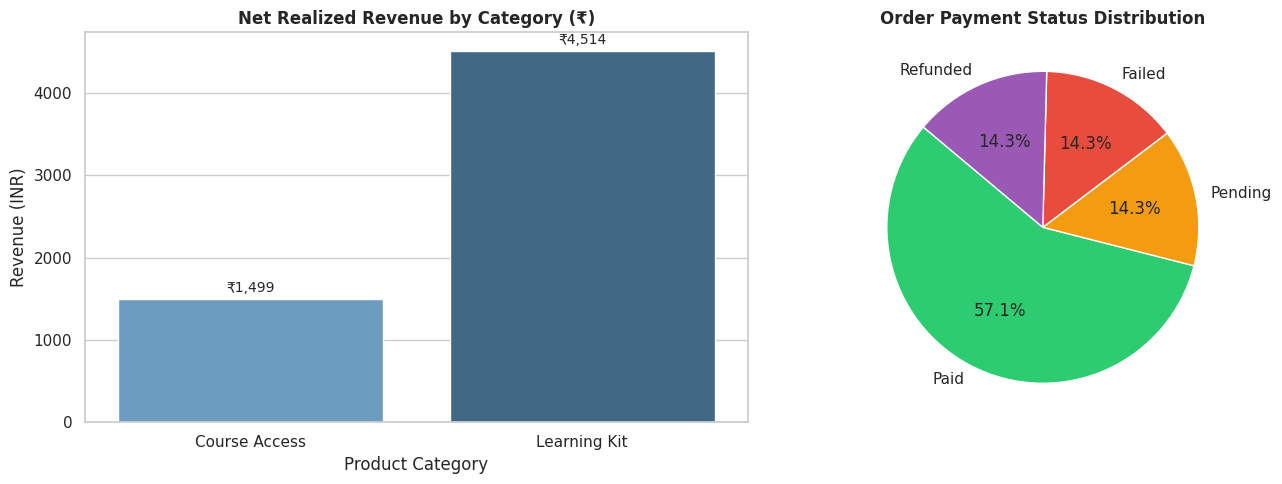

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Revenue by Product Category
sns.barplot(
    data=cat_summary, 
    x='category', 
    y='net_revenue', 
    ax=axes[0], 
    palette='Blues_d'
)
axes[0].set_title('Net Realized Revenue by Category (₹)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue (INR)')
axes[0].set_xlabel('Product Category')
for p in axes[0].patches:
    axes[0].annotate(f"₹{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

# 2. Payment Status Distribution
status_counts = df_clean['payment_status'].value_counts()
axes[1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, 
            colors=['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6'])
axes[1].set_title('Order Payment Status Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('kpi_visualizations.png', dpi=300)
plt.show()

## 7. Key Findings & Data Quality Governance Impact

### Impact of Data Cleansing:
1. **Prevented False Revenue Inflation:** Raw duplicate `RT-1004` and invalid discount `105%` on `RT-1007` would have corrupted GMV and produced negative revenue line items.
2. **Eliminated Negative Quantities:** `RT-1006` (`quantity = -1`) was successfully quarantined, preventing negative inventory distortion.
3. **Harmonized Taxonomy:** Inconsistent casing (`student`, `paid`) normalized across all analytics layers.
4. **Enforced Timeliness & SLAs:** Unparsable dates (`2026-13-10`) and missing dates (`RT-1011`) isolated to protect chronological reporting.
